## PT4.1-K-Nearest-Neighbors

**AI Bootcamp - Instinct Institute**

**Author:** MORK Mongkul

# Exercise 1

You are working as a Data Scientist for a local clinic. You have a small 

dataset of 10 patients with their BMI, Age, and Sugar levels (0 = No Diabetes, 

1 = Diabetes).

| BMI  | Age | Sugar |
|------|-----|-------|
| 33.6 | 50  | 1     |
| 26.6 | 30  | 0     |
| 23.4 | 40  | 0     |
| 43.1 | 67  | 0     |
| 35.3 | 23  | 1     |
| 35.9 | 67  | 1     |
| 36.7 | 45  | 1     |
| 25.7 | 46  | 0     |
| 23.3 | 29  | 0     |
| 31.0 | 56  | 1     |

**Task1:K-NN classification**

**Goal:** Predict if a new patient has high sugar (Diabetes).

- **New Patient Data:** BMI = 30, Age = 45.

- Calculate the Euclidean Distance between this new patient and the first 3 rows of the dataset using the formula:

$$d = \sqrt{(BMI_{new}-BMI_{old})^2+(Age_{new}-Age_{old})^2}$$

- Prediction: If k=3 and the nearest neighbors' labels are [1, 0, 1], what is
the final prediction? Explain the logic of Majority Voting.



In [2]:
#To Do
import numpy as np
BMI = [33.6, 26.6, 23.4, 43.1, 35.3, 35.9, 36.7, 25.7, 23.3, 31.0]
Age = [50, 30, 40, 67, 23, 67, 45, 46, 29, 56]
Sugar = [1, 0, 0, 0, 1, 1, 1, 0, 0, 1]

new_BMI = 30
new_Age = 45

distances =[]

for i in range(3):
    distance = np.sqrt((new_BMI - BMI[i])**2 + (new_Age - Age[i])**2)
    distances.append(distance)
    print(f"Patient {i+1}: BMI = {BMI[i]}, Age = {Age[i]}, Distance = {distance:.2f}")

Patient 1: BMI = 33.6, Age = 50, Distance = 6.16
Patient 2: BMI = 26.6, Age = 30, Distance = 15.38
Patient 3: BMI = 23.4, Age = 40, Distance = 8.28


In [3]:
#prediction with k = 3 and neighbors [1,0,1]
neighbors_labels = [1,0,1]
print(f"Class 0 (No diabetes) count: {neighbors_labels.count(0)}")
print(f"Class 1 (Diabetes) count: {neighbors_labels.count(1)}")

Class 0 (No diabetes) count: 1
Class 1 (Diabetes) count: 2


In [4]:
prediction = 1 if neighbors_labels.count(1) > neighbors_labels.count(0) else 0
print(f"Prediction :{prediction} ({'Diabetes' if prediction == 1 else 'No Diabetes'})")

Prediction :1 (Diabetes)


**Task2:K-NN Regression**

**Goal:** Predict a patient's BMI based on their Age and Sugar status.

- **New Patient Data:** ew Patient Data: Age = 40, Sugar = 1(diabetes).

- Unlike classification, why do we use the average of the neighbors' BMI values instead of voting?.

- Identify the 3 closest neighbors in the dataset. If their BMIs are 33.6, 35.3, and 31.0, calculate the predicted BMI for the new patient.



In [ ]:
#To Do 
BMI = [33.6, 26.6, 23.4, 43.1, 35.3, 35.9, 36.7, 25.7, 23.3, 31.0]
Age = [50, 30, 40, 67, 23, 67, 45, 46, 29, 56]
Sugar = [1, 0, 0, 0, 1, 1, 1, 0, 0, 1]

new_Age = 40 
new_Sugar = 1

In [3]:
neighbors = [33.6,35.3, 31.0]
predict_BMI = sum(neighbors) / len(neighbors)
print(f"Predict BMI for Age {new_Age} and Sugar {new_Sugar}: {predict_BMI:.2f}")

Predict BMI for Age 40 and Sugar 1: 33.30


## Exercise 2

### Auto-MPG Dataset

**Dataset:** https://raw.githubusercontent.com/MorkMongkul/AI-Bootcamp-Instinct/main/Data/auto-mpg.csv 
The Auto-MPG dataset contains information about cars from the 1970s–1980s. Features include:

- `mpg` – miles per gallon (target for regression)  
- `cylinders` – number of cylinders  
- `displacement` – engine displacement  
- `horsepower` – engine horsepower  
- `weight` – vehicle weight  
- `acceleration` – time to accelerate 0–60 mph  
- `model year` – year of the car model  
- `origin` – origin of the car (1: USA, 2: Europe, 3: Japan)  

**Goal:**  
Use K-Nearest Neighbors (K-NN) to build both regression and classification models, understand feature scaling, distance-based modeling, and handle imbalanced data.


**Task 1: K-NN Regression**
**Goal:** Build a K-Nearest Neighbors regression model to predict the `mpg` of cars using the other features. Evaluate the model performance using metrics such as Mean Squared Error, Root Mean Squared Error, Mean Absolute Error, and R² score.



In [21]:
#To Do
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error,mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/MorkMongkul/AI-Bootcamp-Instinct/main/Data/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [5]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [6]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['horsepower'].dtype

dtype('float64')

In [7]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

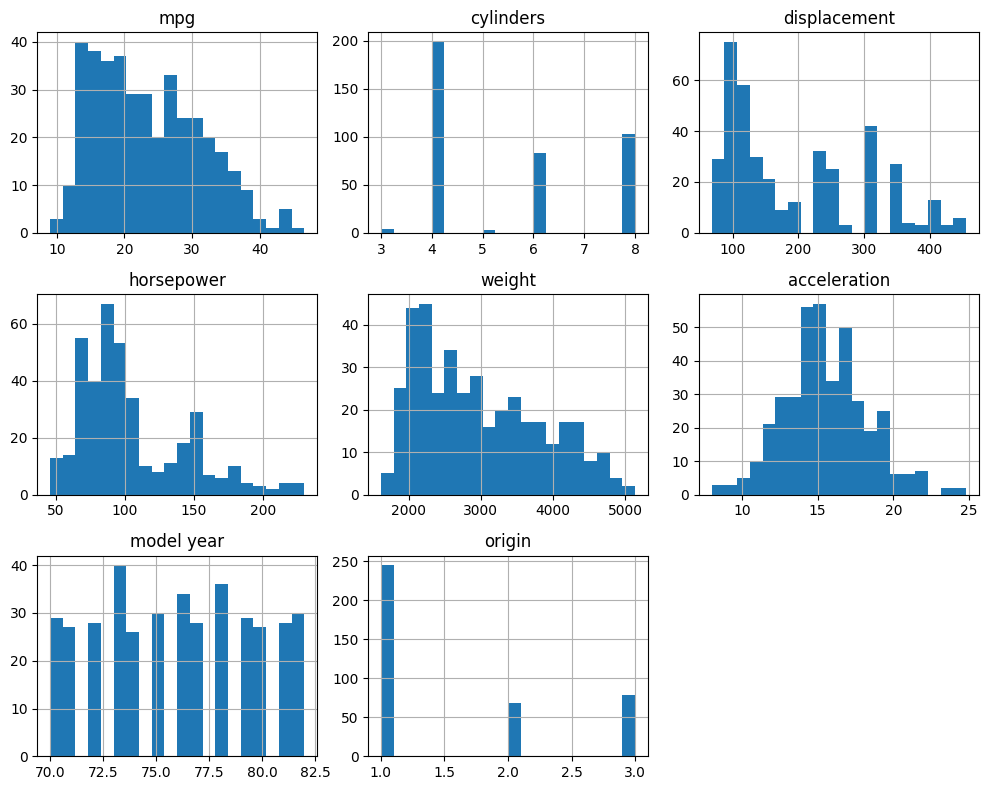

In [10]:
df.hist(figsize=(10,8), bins=20)
plt.tight_layout()
plt.show()

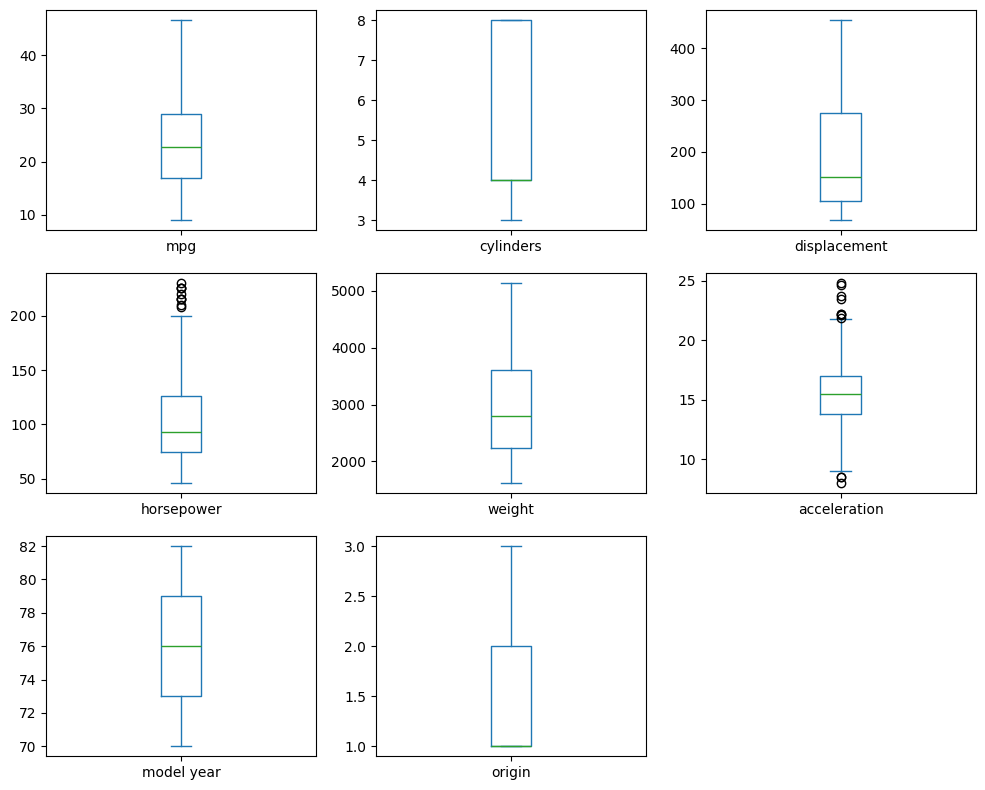

In [11]:
df.select_dtypes(include=['float64','int64']).plot(kind='box',subplots= True,layout=(3,3),figsize=(10,8)) 
plt.tight_layout()
plt.show()

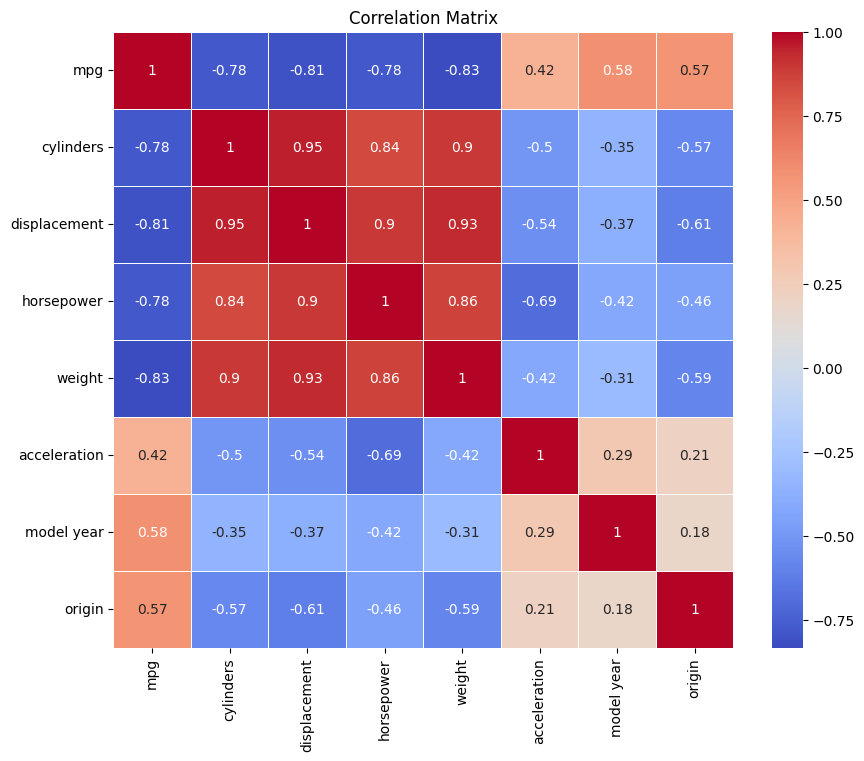

In [12]:
#correlation matrix 
plt.figure(figsize=(10,8))
numerics_df = df.select_dtypes(include=['float64','int64'])
sns.heatmap(numerics_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [16]:
X = df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration','model year','origin']]
y = df['mpg']

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
#split data 
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [19]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [20]:
y_pred = knn_reg.predict(X_test)

In [22]:
#Evaluation 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R2 : {r2:.2f}")

MSE : 7.05
RMSE : 2.66
MAE : 1.98
R2 : 0.86


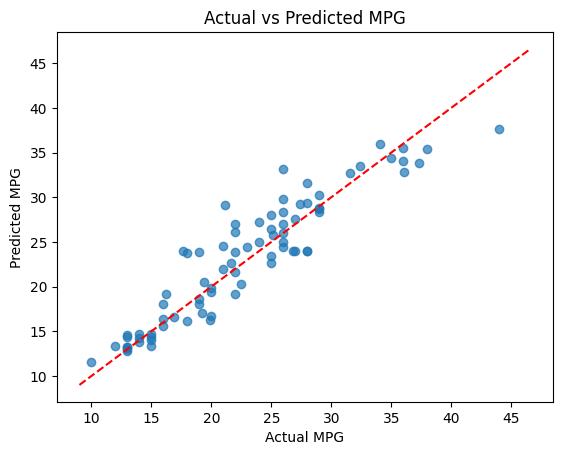

In [23]:
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.show()

**Task 2: K-NN Classification**
**Goal:** Convert `mpg` into a binary target representing car efficiency (`efficient` if `mpg ≥ 30`, `inefficient` if `mpg < 30`) and build a K-Nearest Neighbors classifier to predict car efficiency. Evaluate the model using accuracy, precision, recall, F1-score, and confusion matrix.



In [24]:
#To Do 
df['efficiency_label'] = (df['mpg'] >= 30).astype(int)
y_clf = df['efficiency_label']
y_clf.value_counts() 

efficiency_label
0    302
1     90
Name: count, dtype: int64

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42)

In [27]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [28]:
y_pred = knn_clf.predict(X_test)

In [29]:
#Evaluate the model
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        69
           1       0.71      1.00      0.83        10

    accuracy                           0.95        79
   macro avg       0.86      0.97      0.90        79
weighted avg       0.96      0.95      0.95        79



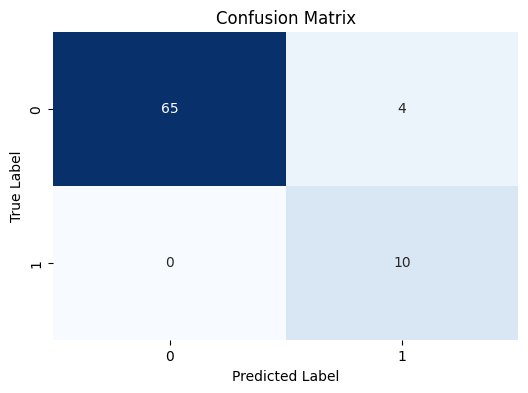

In [30]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Exercise 3: Homework[`heart disease`](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) dataset**


- Reload the heart disease dataset:

- Follow the same procedure as in the previous section on this dataset except that this time, the evaluation metrics are the following:
    - Accuracy
    - Recall
    - Precision
    - F1-score.

- Compare all the performance metrics on the test set and conclude.

In [ ]:
#To Do
